<a href="https://colab.research.google.com/github/Capaquira/projectsLivreLow-code/blob/Notebooks/TauxDesabonnementClients.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import tensorflow as tf

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
    explained_variance_score
)

import warnings
# Ignorar todos los warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

Fuente Original de codigo oreil:

https://github.com/maabel0712/low-code-ai/tree/main/chapter7

https://github.com/maabel0712/low-code-ai/blob/main/chapter7/Customer_Churn_Model.ipynb


In [192]:
Source = pd.read_csv('https://storage.googleapis.com/low-code-ai-book/churn_dataset.csv',on_bad_lines = 'skip',engine='python')
Source.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [193]:
Source.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [194]:
Source.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [195]:
Source

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [196]:
Source['TotalCharges'].describe()

,TotalCharges
count,7043
unique,6531
top,
freq,11


In [197]:
mask = (Source['TotalCharges']==' ')
Source[mask].head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No


In [198]:
mask = (Source['tenure']==0)
Source[mask][['tenure','TotalCharges']]

,tenure,TotalCharges
488,0,
753,0,
936,0,
1082,0,
1340,0,
3331,0,
3826,0,
4380,0,
5218,0,
6670,0,


In [199]:
df_1 = Source.replace({'TotalCharges': {' ': 0.0}})
mask = (Source['tenure']==0)
df_1[mask][['tenure','TotalCharges']]

,tenure,TotalCharges
488,0,0.0
753,0,0.0
936,0,0.0
1082,0,0.0
1340,0,0.0
3331,0,0.0
3826,0,0.0
4380,0,0.0
5218,0,0.0
6670,0,0.0


In [200]:
df_2 = df_1.astype({'TotalCharges':'float64'})
df_2.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [201]:
df_2.describe().round(3)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000,7043.000,7043.000,7043.000
mean,0.162,32.371,64.762,2279.734
std,0.369,24.559,30.090,2266.794
min,0.000,0.000,18.250,0.000
25%,0.000,9.000,35.500,398.550
50%,0.000,29.000,70.350,1394.550
75%,0.000,55.000,89.850,3786.600
max,1.000,72.000,118.750,8684.800


Include Objets columns

In [202]:
df_2.describe(include='object').T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [203]:
df_2.value_counts(['PhoneService','MultipleLines'])

PhoneService  MultipleLines   
Yes           No                  3390
              Yes                 2971
No            No phone service     682
Name: count, dtype: int64

In [204]:
df_2.value_counts(['InternetService','OnlineSecurity'])

InternetService  OnlineSecurity     
Fiber optic      No                     2257
No               No internet service    1526
DSL              No                     1241
                 Yes                    1180
Fiber optic      Yes                     839
Name: count, dtype: int64

In [205]:
df_2.value_counts(['InternetService', 'OnlineSecurity', 'OnlineBackup', 'StreamingTV', 'StreamingMovies'])

InternetService  OnlineSecurity       OnlineBackup         StreamingTV          StreamingMovies    
No               No internet service  No internet service  No internet service  No internet service    1526
Fiber optic      No                   No                   No                   No                      521
                                                           Yes                  Yes                     455
DSL              No                   No                   No                   No                      453
Fiber optic      No                   Yes                  Yes                  Yes                     428
                 Yes                  Yes                  Yes                  Yes                     270
DSL              Yes                  No                   No                   No                      246
                                      Yes                  No                   No                      233
Fiber optic      No                   No                   No                   Yes                     215
                                                           Yes                  No                      212
DSL              Yes                  Yes                  Yes                  Yes                     209
Fiber optic      No                   Yes                  No                   No                      192
DSL              No                   Yes                  No                   No                      181
Fiber optic      Yes                  No                   Yes                  Yes                     157
DSL              No                   No                   Yes                  Yes                     144
                 Yes                  No                   Yes                  Yes                     139
                 No                   Yes                  Yes                  Yes                     138
Fiber optic      No                   Yes                  Yes                  No                      119
                                                           No                   Yes                     115
                 Yes                  No                   No                   No                      107
DSL              Yes                  Yes                  No                   Yes                     100
                 No                   No                   No                   Yes                     100
                                                           Yes                  No                       95
                 Yes                  Yes                  Yes                  No                       95
                                      No                   No                   Yes                      88
Fiber optic      Yes                  Yes                  No                   No                       85
DSL              Yes                  No                   Yes                  No                       70
Fiber optic      Yes                  Yes                  Yes                  No                       67
DSL              No                   Yes                  Yes                  No                       67
Fiber optic      Yes                  Yes                  No                   Yes                      67
DSL              No                   Yes                  No                   Yes                      63
Fiber optic      Yes                  No                   No                   Yes                      44
                                                           Yes                  No                       42
Name: count, dtype: int64

<Axes: xlabel='Contract'>

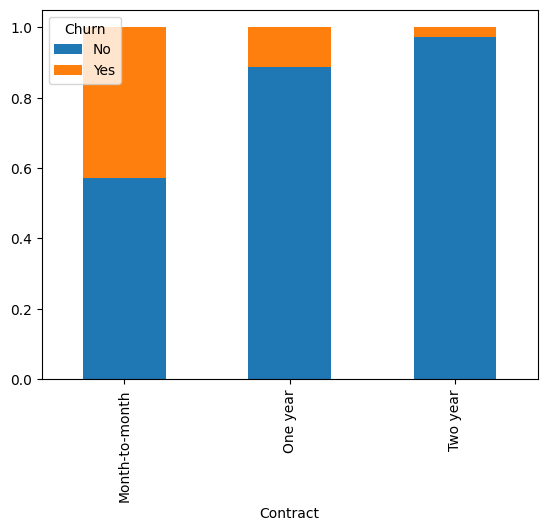

In [206]:
(df_2.groupby('Contract')['Churn'].value_counts(normalize=True)
  .unstack('Churn')
  .plot.bar(stacked=True))

In [207]:
def plot_cat_feature_dist(feature_name):
  (df_2.groupby(feature_name)['Churn'].value_counts(normalize=True)
    .unstack('Churn')
    .plot.bar(stacked=True))

In [208]:
df_2.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [209]:
type

type

In [210]:
#features = df_2.columns
#for feature in features:
#  plot_cat_feature_dist(feature)

In [211]:
df_2['AvgMonthlyCharge'] = df_2['TotalCharges']/df_2['tenure']
df_2['DiffCharges'] = df_2['MonthlyCharges']-df_2['AvgMonthlyCharge']
df_2['DiffCharges'].describe()

,DiffCharges
count,7032.000000
mean,-0.001215
std,2.616165
min,-18.900000
25%,-1.160179
50%,0.000000
75%,1.147775
max,19.125000


In [212]:
df_2['AvgMonthlyCharge'] = df_2['TotalCharges'].div(df_2['tenure']).replace(np.inf,0)
df_2['DiffCharges'] = df_2['MonthlyCharges']-df_2['AvgMonthlyCharge']
df_2['DiffCharges'].describe()

,DiffCharges
count,7032.000000
mean,-0.001215
std,2.616165
min,-18.900000
25%,-1.160179
50%,0.000000
75%,1.147775
max,19.125000


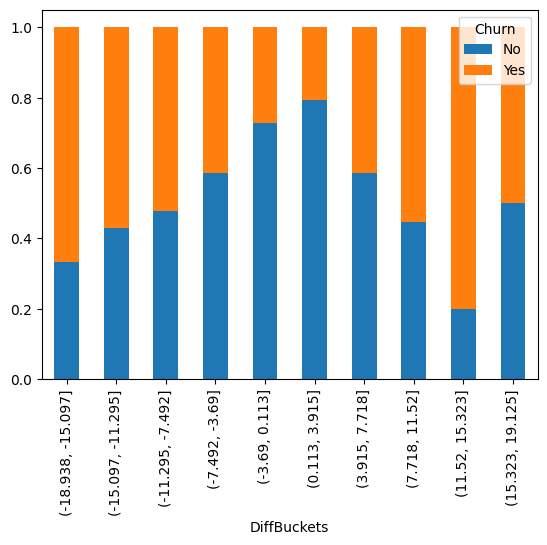

In [213]:
df_2['DiffBuckets'] = pd.cut(df_2['DiffCharges'], bins=10)
plot_cat_feature_dist('DiffBuckets')

# df_2['DiffBuckets'] = pd.cut(df_2['DiffCharges'].values, bins=5)
# plot_cat_feature_dist('DiffBuckets')

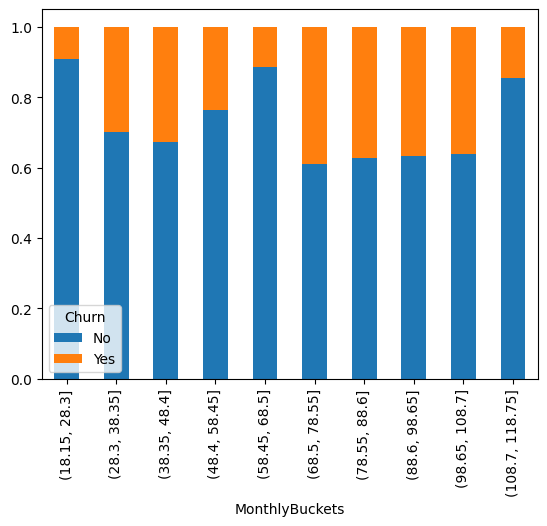

In [214]:
df_2['MonthlyBuckets'] = pd.cut(df_2['MonthlyCharges'], bins=10)
plot_cat_feature_dist('MonthlyBuckets')

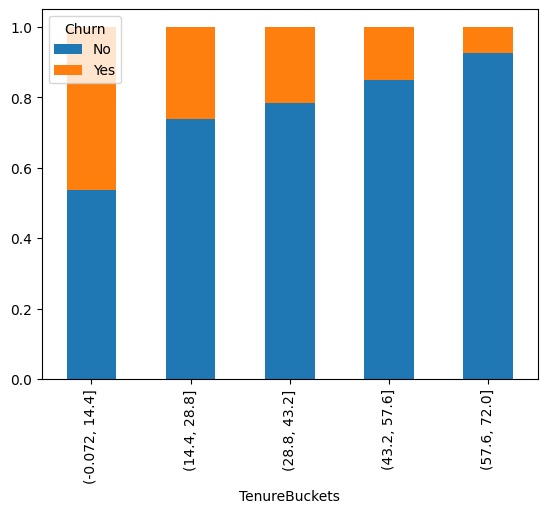

In [215]:
df_2['TenureBuckets'] = pd.cut(df_2['tenure'], bins=5)
plot_cat_feature_dist('TenureBuckets')

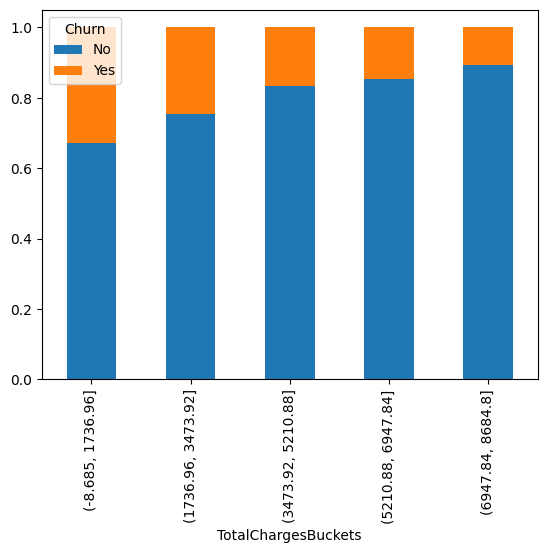

In [216]:
df_2['TotalChargesBuckets'] = pd.cut(df_2['TotalCharges'], bins=5)
plot_cat_feature_dist('TotalChargesBuckets')

Data Transformation

In [217]:
df_3 = df_2.copy()
df_3 = df_3.drop(columns=['gender','StreamingTV',
                          'StreamingMovies','PhoneService'])
df_3.columns

Index(['customerID', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'AvgMonthlyCharge', 'DiffCharges', 'DiffBuckets', 'MonthlyBuckets',
       'TenureBuckets', 'TotalChargesBuckets'],
      dtype='object')

In [218]:
df_3 =df_3.drop(columns=['TotalCharges','AvgMonthlyCharge',
                         'DiffCharges','MonthlyBuckets'])

df_3.columns

Index(['customerID', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'Churn', 'DiffBuckets',
       'TenureBuckets', 'TotalChargesBuckets'],
      dtype='object')

In [219]:
df_3 =df_3.drop(columns=['TenureBuckets','TotalChargesBuckets','customerID'])

df_3.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'Churn', 'DiffBuckets'],
      dtype='object')

In [220]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   SeniorCitizen     7043 non-null   int64   
 1   Partner           7043 non-null   object  
 2   Dependents        7043 non-null   object  
 3   tenure            7043 non-null   int64   
 4   MultipleLines     7043 non-null   object  
 5   InternetService   7043 non-null   object  
 6   OnlineSecurity    7043 non-null   object  
 7   OnlineBackup      7043 non-null   object  
 8   DeviceProtection  7043 non-null   object  
 9   TechSupport       7043 non-null   object  
 10  Contract          7043 non-null   object  
 11  PaperlessBilling  7043 non-null   object  
 12  PaymentMethod     7043 non-null   object  
 13  MonthlyCharges    7043 non-null   float64 
 14  Churn             7043 non-null   object  
 15  DiffBuckets       7032 non-null   category
dtypes: category(1), float64(

In [221]:
df_3.describe().round(3)

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000,7043.000,7043.000
mean,0.162,32.371,64.762
std,0.369,24.559,30.090
min,0.000,0.000,18.250
25%,0.000,9.000,35.500
50%,0.000,29.000,70.350
75%,0.000,55.000,89.850
max,1.000,72.000,118.750


In [222]:
df_3

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,DiffBuckets
0,0,Yes,No,1,No phone service,DSL,No,Yes,No,No,Month-to-month,Yes,Electronic check,29.85,No,"(-3.69, 0.113]"
1,0,No,No,34,No,DSL,Yes,No,Yes,No,One year,No,Mailed check,56.95,No,"(0.113, 3.915]"
2,0,No,No,2,No,DSL,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,53.85,Yes,"(-3.69, 0.113]"
3,0,No,No,45,No phone service,DSL,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),42.30,No,"(0.113, 3.915]"
4,0,No,No,2,No,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes,"(-7.492, -3.69]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,Yes,Yes,24,Yes,DSL,Yes,No,Yes,Yes,One year,Yes,Mailed check,84.80,No,"(0.113, 3.915]"
7039,0,Yes,Yes,72,Yes,Fiber optic,No,Yes,Yes,No,One year,Yes,Credit card (automatic),103.20,No,"(0.113, 3.915]"
7040,0,Yes,Yes,11,No phone service,DSL,Yes,No,No,No,Month-to-month,Yes,Electronic check,29.60,No,"(-3.69, 0.113]"
7041,1,Yes,No,4,Yes,Fiber optic,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,Yes,"(-3.69, 0.113]"


In [223]:
df_prep = df_3.replace('No internet service', 'No')
df_prep[['OnlineSecurity', 'OnlineBackup',
         'DeviceProtection', 'TechSupport']].nunique()

,0
OnlineSecurity,2
OnlineBackup,2
DeviceProtection,2
TechSupport,2


In [224]:
from sklearn.preprocessing import OneHotEncoder

numeric_columns = ['SeniorCitizen', 'tenure', 'MonthlyCharges']
categorical_columns = ['Partner', 'Dependents', 'MultipleLines',
                       'InternetService','OnlineSecurity',
                       'OnlineBackup','DeviceProtection',
                       'TechSupport','Contract','PaperlessBilling',
                       'PaymentMethod','DiffBuckets']

X_num = df_prep[numeric_columns]
X_cat = df_prep[categorical_columns]

ohe = OneHotEncoder(drop='if_binary')
X_cat_trans = ohe.fit_transform(X_cat)

In [225]:
X_cat_trans.toarray()[0]

array([1., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0.,
       0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [226]:
ohe.inverse_transform(X_cat_trans.toarray())[0]

array(['Yes', 'No', 'No phone service', 'DSL', 'No', 'Yes', 'No', 'No',
       'Month-to-month', 'Yes', 'Electronic check',
       Interval(-3.69, 0.113, closed='right')], dtype=object)

In [227]:
X = np.concatenate((X_num.values,X_cat_trans.toarray()), axis=1)
y = df_prep['Churn'].values

In [228]:
X

array([[  0.  ,   1.  ,  29.85, ...,   0.  ,   0.  ,   0.  ],
       [  0.  ,  34.  ,  56.95, ...,   0.  ,   0.  ,   0.  ],
       [  0.  ,   2.  ,  53.85, ...,   0.  ,   0.  ,   0.  ],
       ...,
       [  0.  ,  11.  ,  29.6 , ...,   0.  ,   0.  ,   0.  ],
       [  1.  ,   4.  ,  74.4 , ...,   0.  ,   0.  ,   0.  ],
       [  0.  ,  66.  , 105.65, ...,   0.  ,   0.  ,   0.  ]])

In [229]:
y

array(['No', 'No', 'Yes', ..., 'No', 'Yes', 'No'], dtype=object)

In [230]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
0,0.0,1.0,29.85,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,34.0,56.95,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,2.0,53.85,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,45.0,42.30,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,2.0,70.70,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,24.0,84.80,1.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7039,0.0,72.0,103.20,1.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7040,0.0,11.0,29.60,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7041,1.0,4.0,74.40,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [231]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=113)

X_train.shape

(5634, 34)

# **Creacion del modelo de regresion lineal con Logistic Regression**

In [232]:
from sklearn.linear_model import LogisticRegression

cls = LogisticRegression()

cls.fit(X_train, y_train)

LogisticRegression()

In [233]:
cls.score(X_test, y_test)

0.8026969481902059

In [234]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

cls = LogisticRegression()

cls.fit(X_train_scaled, y_train)

LogisticRegression()

In [235]:
cls.score(X_test, y_test)

0.47764371894960966

In [236]:
cls.score(scaler.fit_transform(X_test), y_test)

0.801277501774308

In [237]:
X_test_scaled = scaler.transform(X_test)

cls.score(X_test_scaled, y_test)

0.801277501774308

In [238]:
from sklearn.metrics import confusion_matrix

y_pred = cls.predict(X_test_scaled)

confusion_matrix(y_test, y_pred, labels=['Yes','No'])

array([[189, 183],
       [ 97, 940]])

In [239]:
from sklearn.metrics import precision_score, recall_score

print("Precision:", precision_score(y_test, y_pred,
                                    labels=['Yes','No'], pos_label='Yes'))

print("Recall:", recall_score(y_test, y_pred,
                              labels=['Yes','No'], pos_label='Yes'))

Precision: 0.6608391608391608
Recall: 0.5080645161290323


## **Serving Predictions with a Trained Model in Scikit-Learn**

In [240]:
import json

# Code in book for the example slightly differs due to spacing considerations
example = json.loads('{"customerID": "7090-HPOJU", "gender": "Female", "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "Yes", "tenure": 66,"PhoneService": "Yes", "MultipleLines": "Yes", "InternetService": "DSL","OnlineSecurity": "Yes", "OnlineBackup": "Yes", "DeviceProtection": "Yes","TechSupport": "No", "StreamingTV": "No", "StreamingMovies": "No","Contract": "Month-to-month", "PaperlessBilling": "Yes", "PaymentMethod": "Bank transfer (automatic)", "MonthlyCharges": 67.45, "TotalCharges": "4508.65"}')

ex_df = pd.DataFrame([example])
ex_df['TotalCharges'] = ex_df['TotalCharges'].astype('float64')
ex_df = ex_df.drop(columns=['customerID','gender',
                            'StreamingTV','StreamingMovies',
                            'PhoneService'])

ex_df['AvgMonthlyCharge'] = ex_df['TotalCharges']/ex_df['tenure']
ex_df['DiffCharges'] = ex_df['MonthlyCharges']-ex_df['AvgMonthlyCharge']
ex_df['DiffBuckets'] = pd.cut(ex_df['DiffCharges'],
                           bins=[-18.938,-11.295,-3.69,3.915,11.52,19.125])
ex_df.pop('DiffCharges')

numeric_columns = ['SeniorCitizen', 'tenure', 'MonthlyCharges']
categorical_columns = ['Partner', 'Dependents', 'MultipleLines',
                       'InternetService','OnlineSecurity','OnlineBackup',
                       'DeviceProtection','TechSupport','Contract',
                       'PaperlessBilling','PaymentMethod','DiffBuckets']

X_num = df_prep[numeric_columns]
X_cat = df_prep[categorical_columns]

X_cat_trans = ohe.transform(X_cat)

X = np.concatenate((X_num.values,X_cat_trans.toarray()), axis=1)
X_scaled = scaler.transform(X)

cls.predict(X)

array(['Yes', 'Yes', 'Yes', ..., 'Yes', 'Yes', 'Yes'], dtype=object)

In [241]:
import joblib

joblib.dump(cls, 'filename.joblib')

cls = joblib.load('filename.joblib')

# **Pipeline**

In [242]:
def transform_fn(df):

  df = df.replace({'TotalCharges': {' ': 0.0}})
  df = df.astype({'TotalCharges':'float64'})

  df['AvgMonthlyCharge']= df['TotalCharges'].div(df['tenure'],
                                                      fill_values=0.0)

  df['DiffCharges'] = df['MonthlyCharges']-df['AvgMonthlyCharge']

  df['DiffBuckets'] = pd.cut(df['DiffCharges'], bins=5)

  df = df.drop(columns=['AvgMonthlyCharge', 'gender','StreamingTV',
                            'StreamingMovies','PhoneService',
                            'customerID', 'DiffCharges'])
  return df

In [243]:
numeric_columns = ['SeniorCitizen', 'tenure', 'MonthlyCharges']
categorical_columns = ['Partner', 'Dependents', 'MultipleLines',
                      'InternetService','OnlineSecurity',
                      'OnlineBackup', 'DeviceProtection',
                      'TechSupport','Contract',
                      'PaperlessBilling','PaymentMethod',
                      'DiffBuckets']

In [244]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer


fn_transformer = FunctionTransformer(transform_fn)
col_transformer = ColumnTransformer(
  [('ohe', OneHotEncoder(drop='if_binary'), categorical_columns),
  ('sca', MinMaxScaler(), numeric_columns)])
model = LogisticRegression()

In [245]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([('preproc', fn_transformer),
                 ('col_trans', col_transformer),
                 ('model', model)])